In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from ipywidgets import interact, FloatSlider
from sklearn.ensemble import RandomForestClassifier

%config InlineBackend.figure_format = 'retina'

In [2]:
data = pd.read_csv('/Users/konansul/Downloads/framingham.csv')

In [3]:
data

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [5]:
data.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

<Axes: >

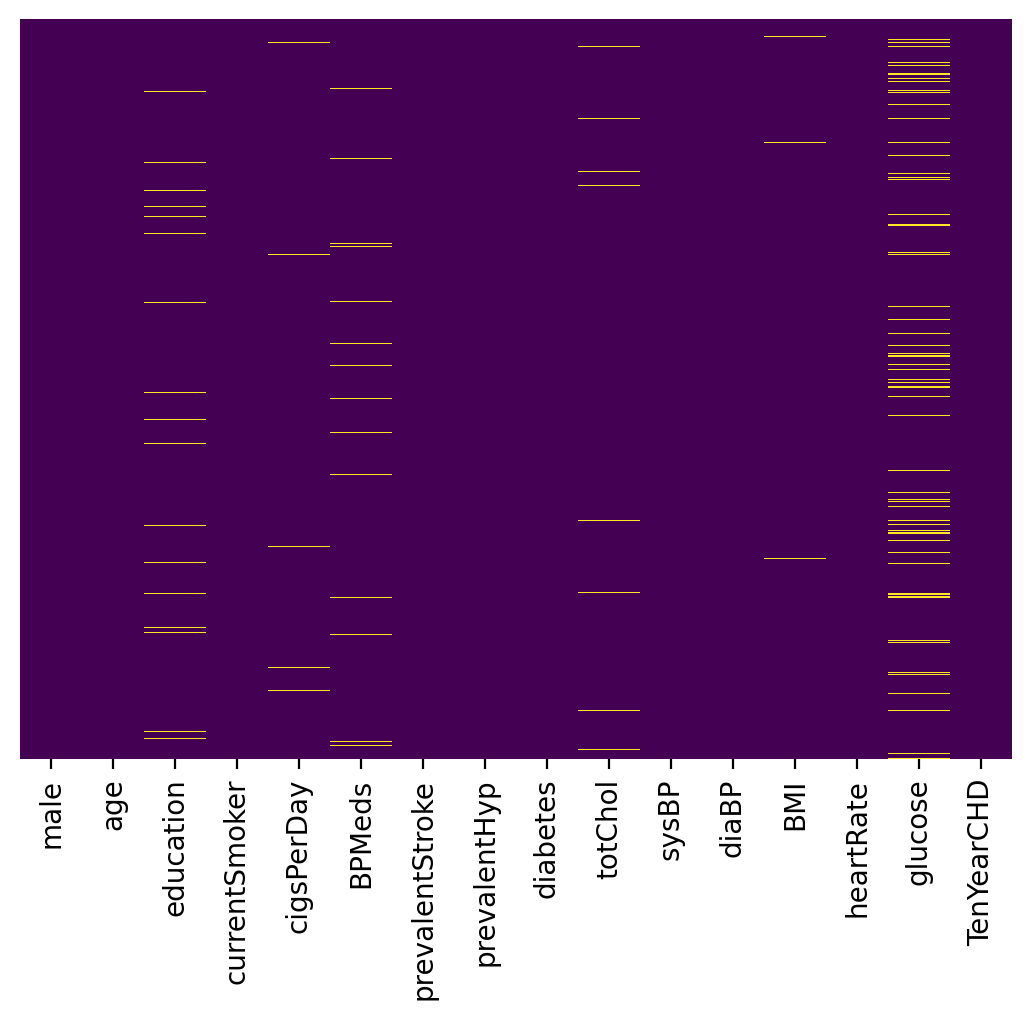

In [6]:
sns.heatmap(data.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')

In [7]:
data.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


<Axes: >

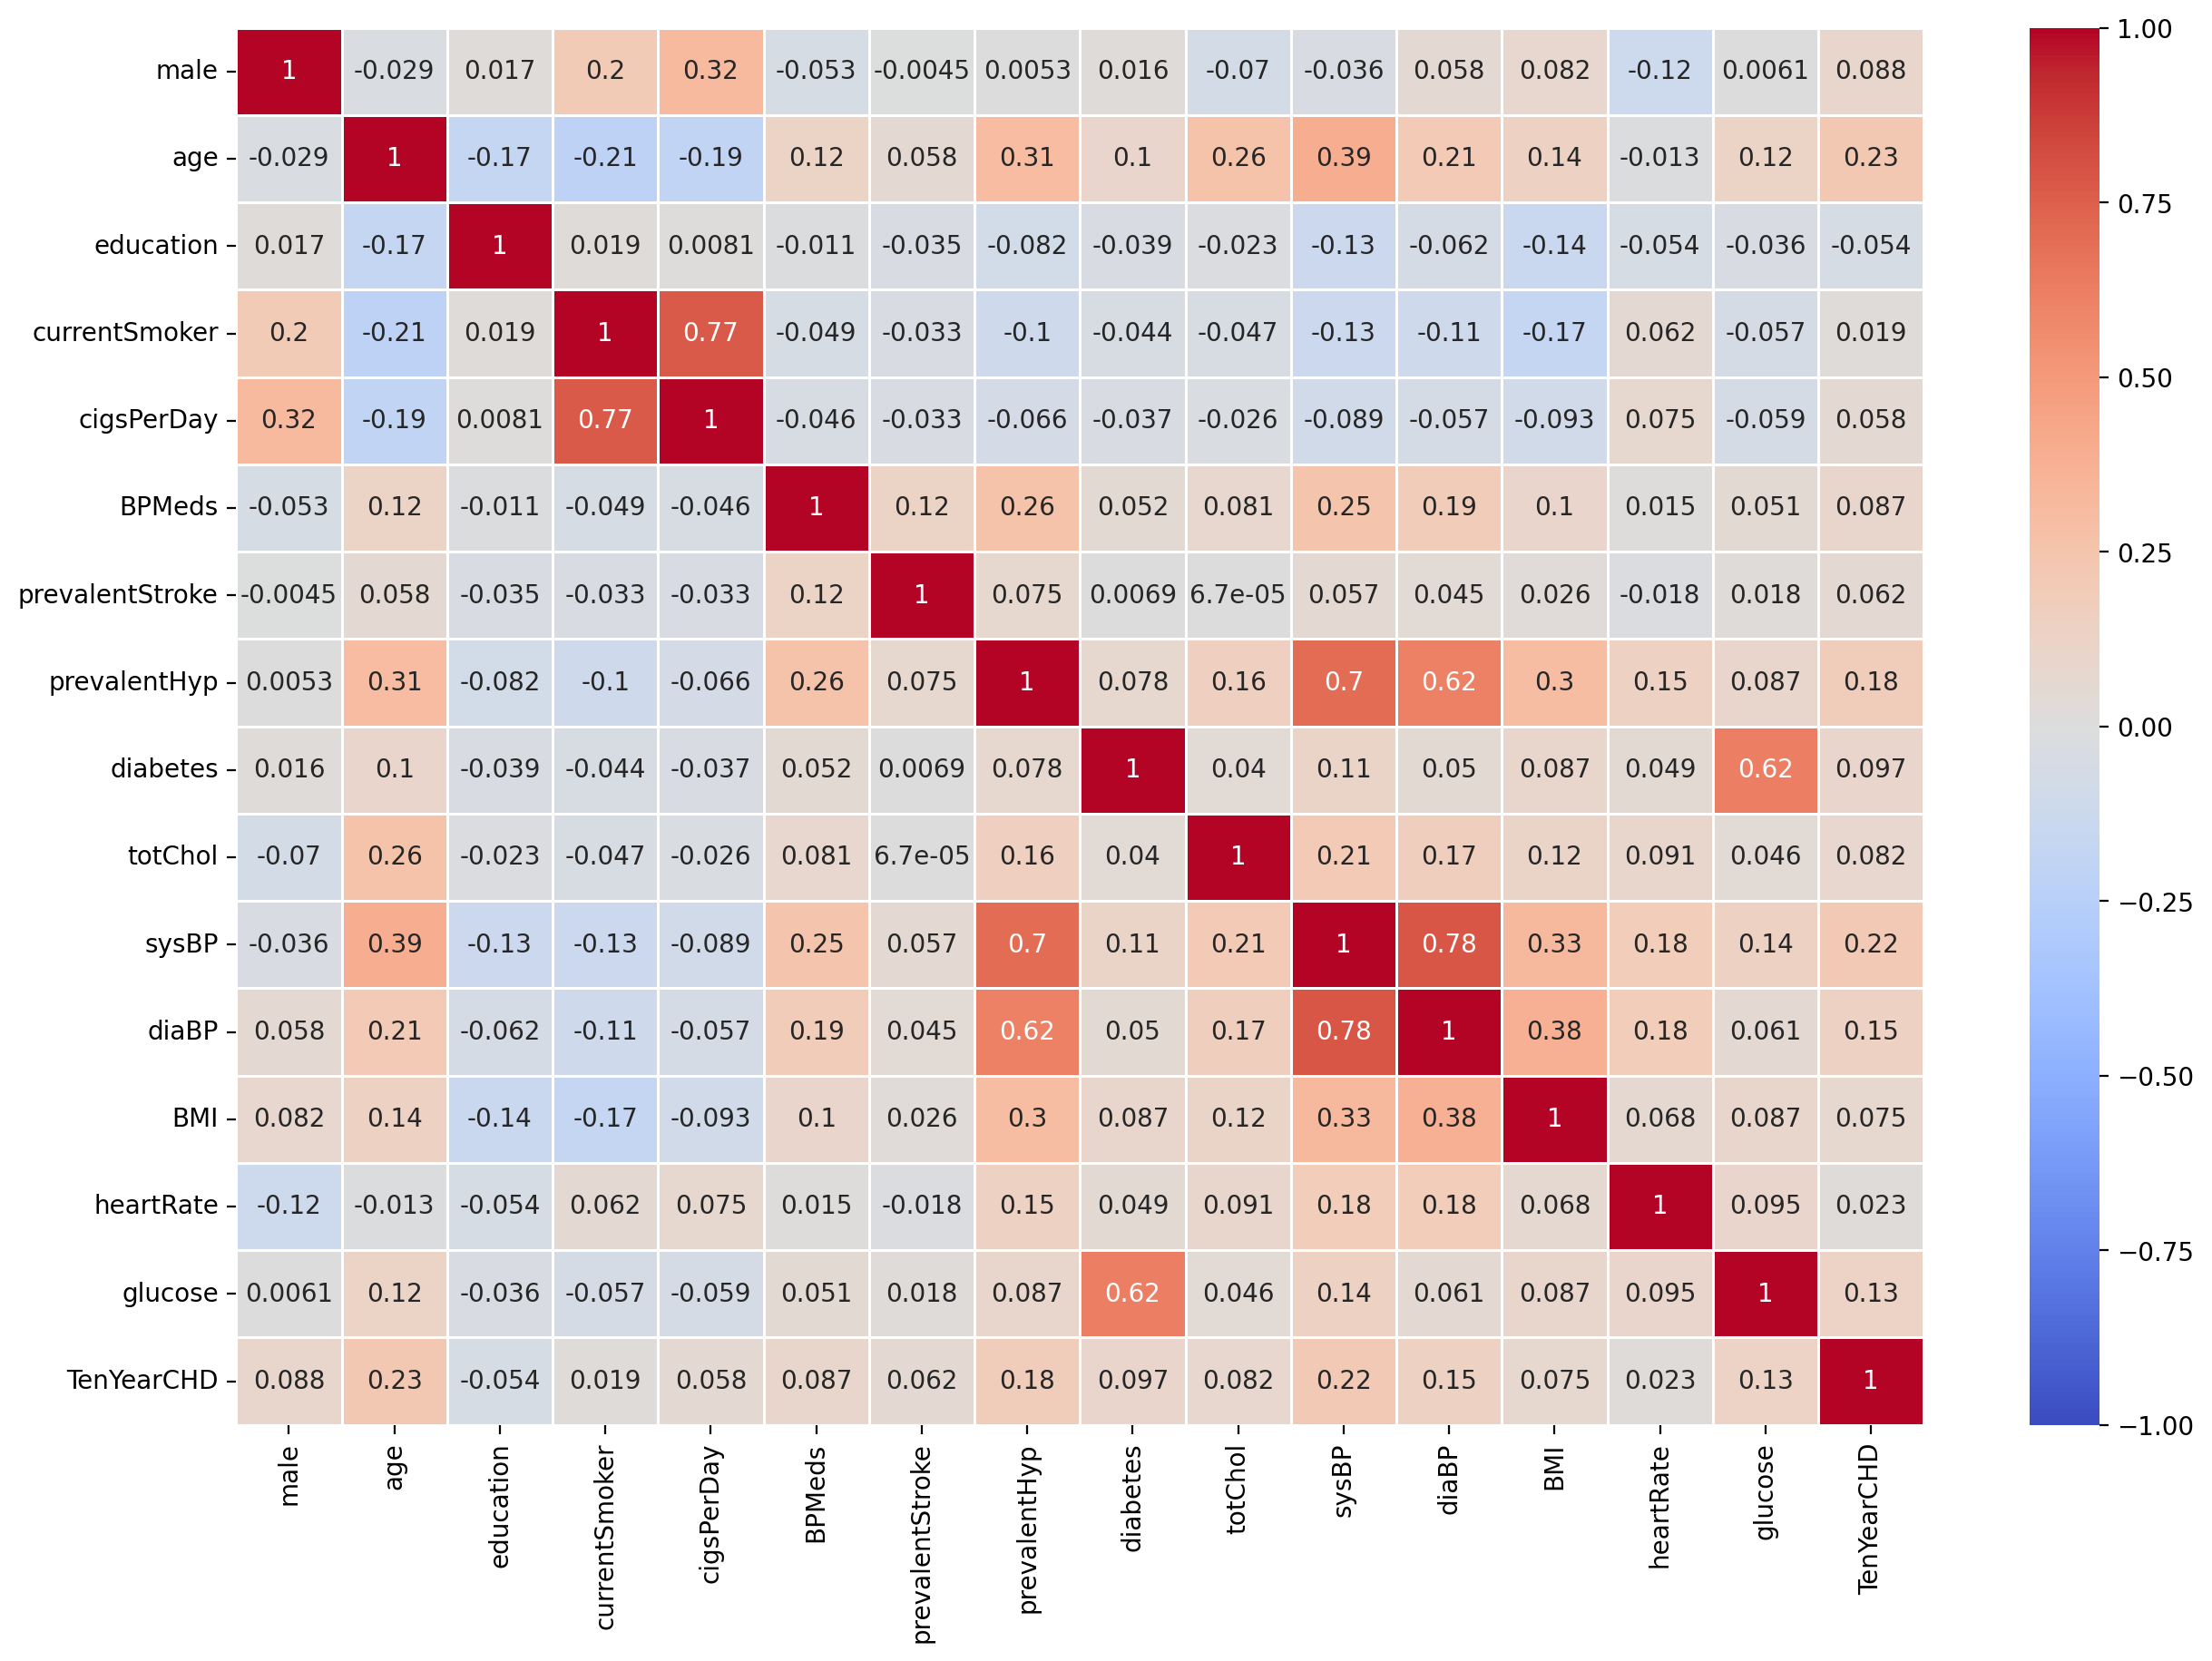

In [8]:
plt.figure(figsize = (15,10))
sns.heatmap(data.corr(), annot = True, cmap = 'coolwarm', linewidths = 0.5, vmin = -1, vmax = 1)

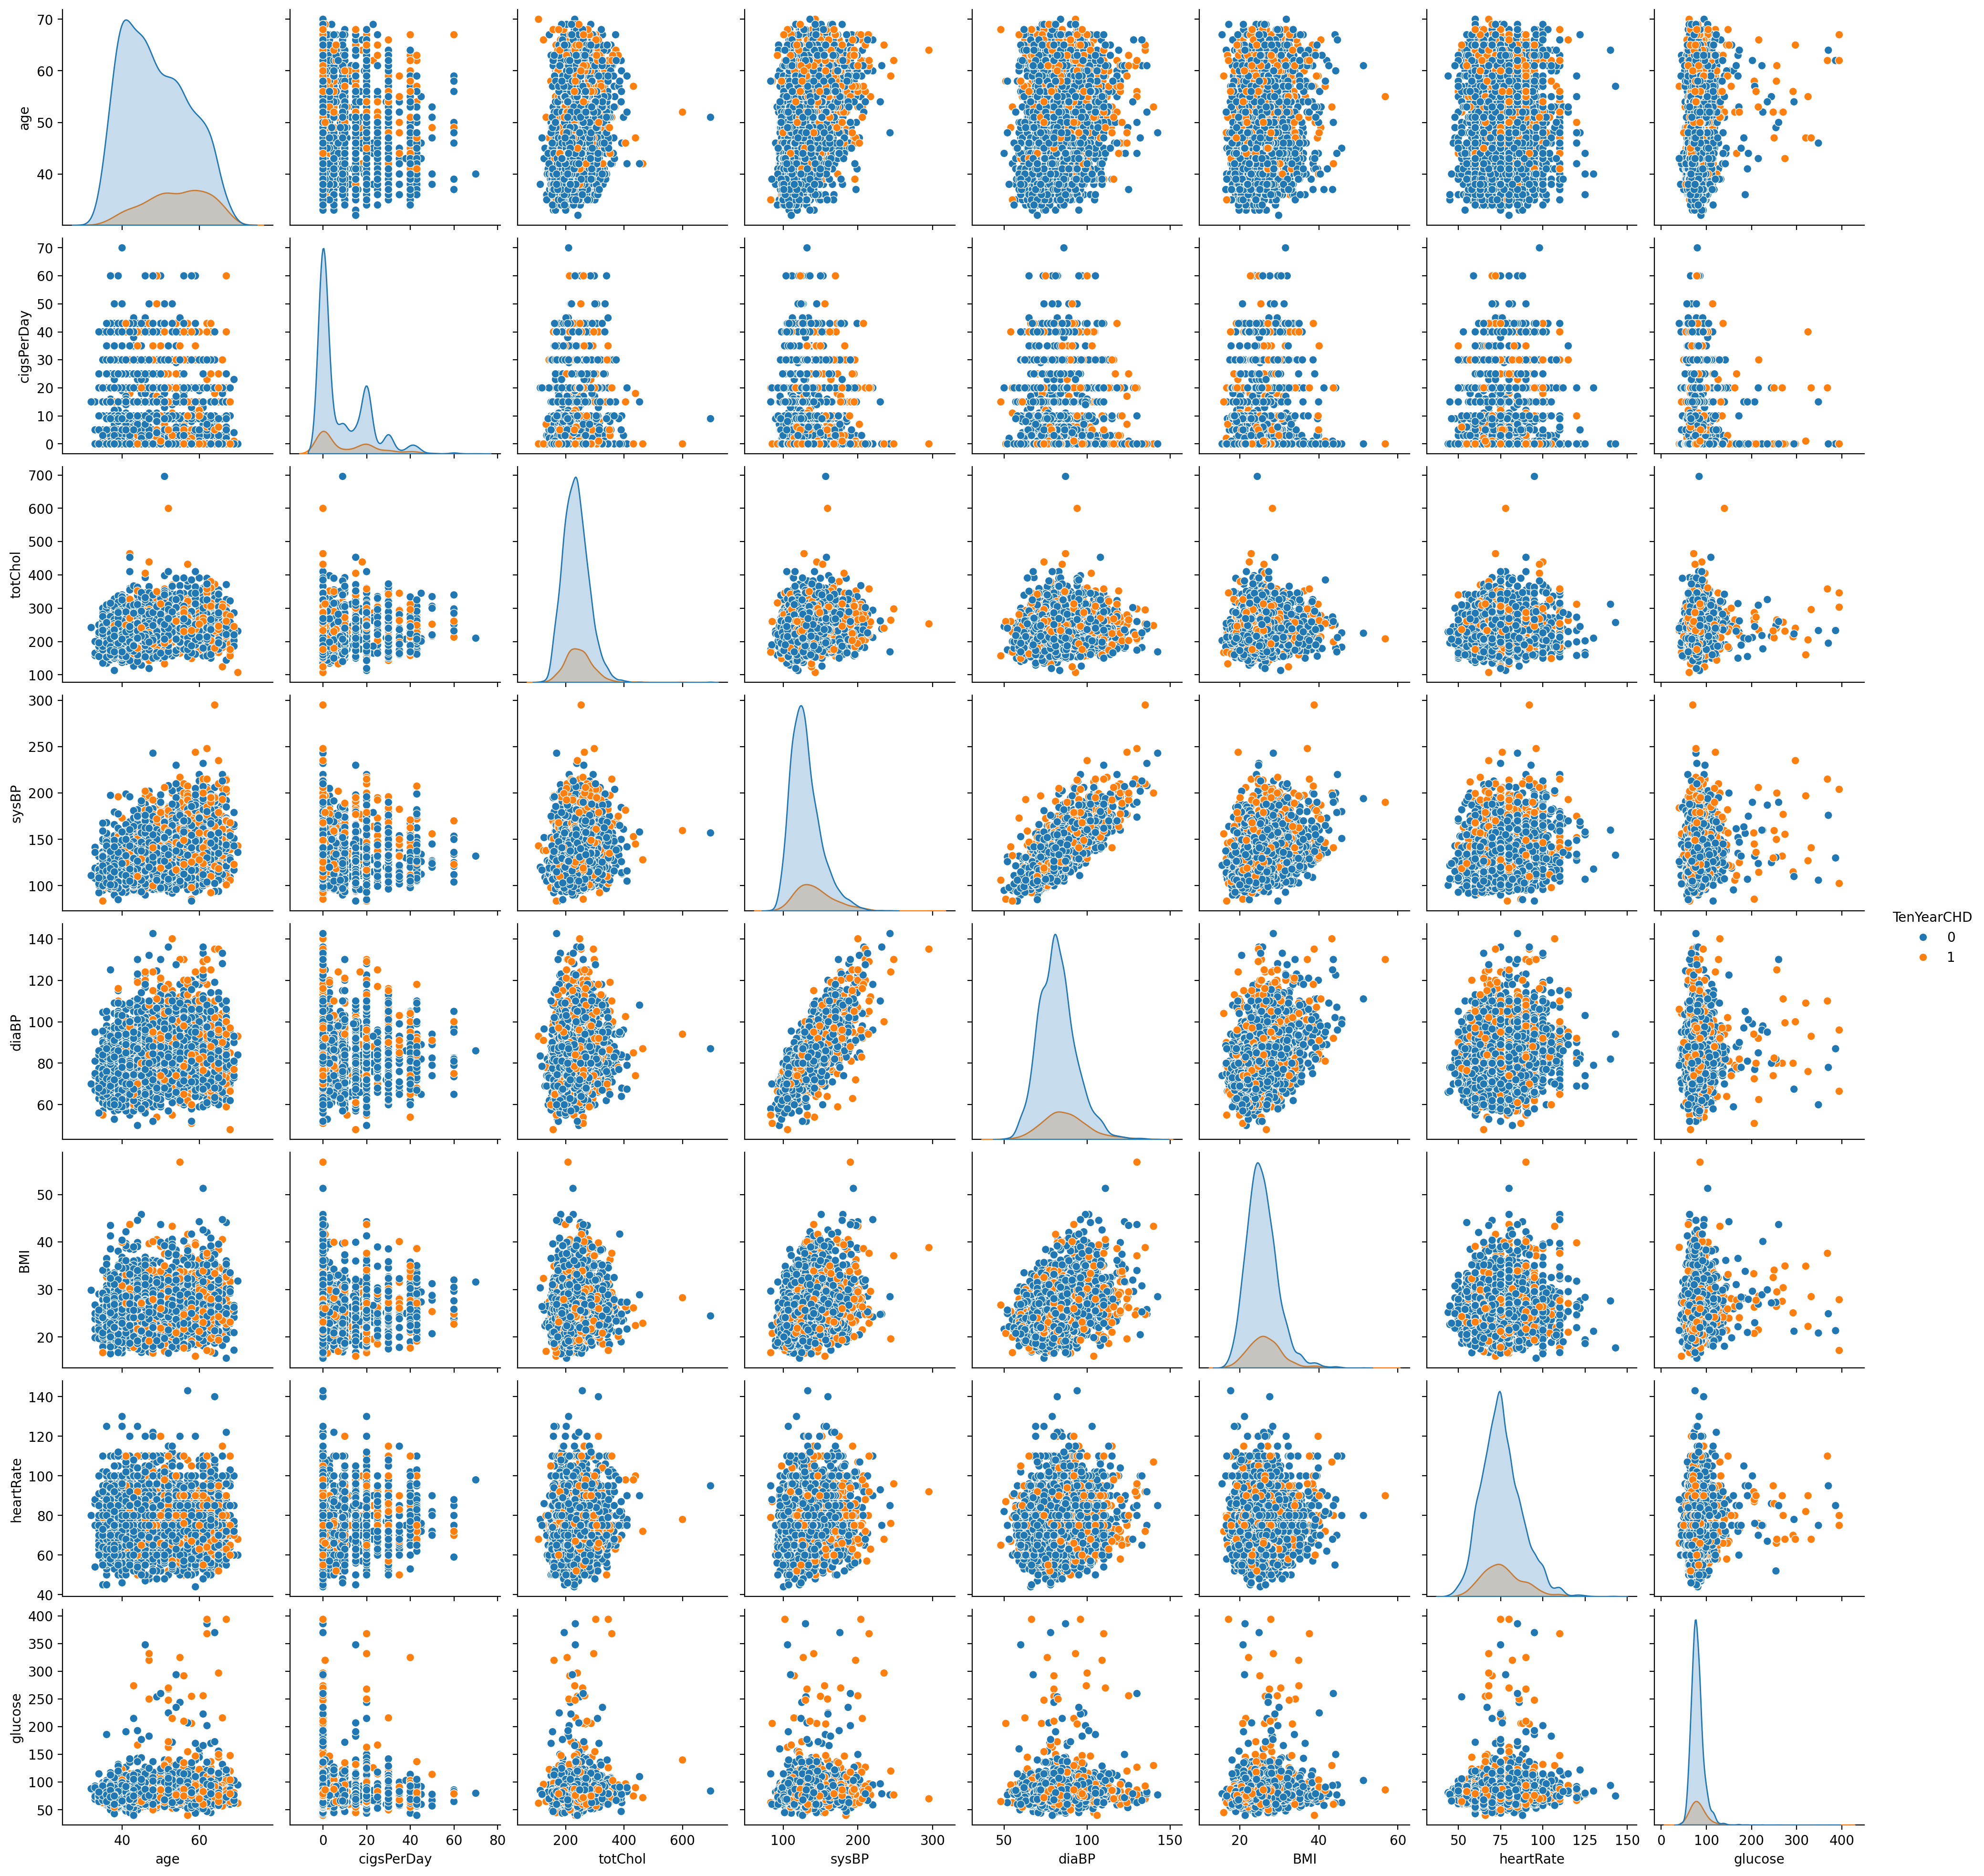

In [9]:
sns.pairplot(data[['age', 'cigsPerDay', 'totChol', 'sysBP',	'diaBP', 'BMI', 'heartRate','glucose', 'TenYearCHD']], hue = 'TenYearCHD')

In [10]:
data.corr()['TenYearCHD']

male               0.088428
age                0.225256
education         -0.054059
currentSmoker      0.019456
cigsPerDay         0.057884
BPMeds             0.087489
prevalentStroke    0.061810
prevalentHyp       0.177603
diabetes           0.097317
totChol            0.082184
sysBP              0.216429
diaBP              0.145299
BMI                0.075192
heartRate          0.022913
glucose            0.125544
TenYearCHD         1.000000
Name: TenYearCHD, dtype: float64

In [11]:
data['education'].value_counts()

education
1.0    1720
2.0    1253
3.0     687
4.0     473
Name: count, dtype: int64

In [12]:
data = data.drop('education', axis = 1)

In [13]:
data[data['cigsPerDay'].isna()][:5]

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
131,1,43,1,NaN,0.0,0,0,0,222.0,109.5,69.0,25.50,75.0,NaN,0
139,1,49,1,NaN,0.0,0,0,0,256.0,127.5,81.5,28.21,93.0,85.0,1
1046,0,49,1,NaN,0.0,0,0,0,280.0,120.0,80.0,22.33,90.0,75.0,0
1292,1,42,1,NaN,0.0,0,0,0,225.0,122.5,80.0,25.54,90.0,90.0,0
1347,0,58,1,NaN,0.0,0,1,0,270.0,195.0,117.5,23.35,75.0,NaN,0


In [14]:
data['cigsPerDay'] = data['cigsPerDay'].fillna(np.mean(data['cigsPerDay']))

In [15]:
data['BPMeds'].value_counts()

BPMeds
0.0    4061
1.0     124
Name: count, dtype: int64

In [16]:
data['BPMeds'] = data['BPMeds'].fillna(0.0)

In [17]:
data['totChol'] = data['totChol'].fillna(np.mean(data['totChol']))

In [18]:
data['BMI'] = data['BMI'].fillna(np.mean(data['BMI']))

In [19]:
data[data['heartRate'].isna()]

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
689,1,64,1,18.0,0.0,0,1,0,219.0,172.5,75.0,29.29,NaN,91.0,1


In [20]:
data.groupby('male')['heartRate'].mean()

male
0    77.094667
1    74.261276
Name: heartRate, dtype: float64

In [21]:
data['heartRate'] = data['heartRate'].fillna(data.groupby('male')['heartRate'].mean()[1])

In [22]:
data['glucose'] = data['glucose'].fillna(np.mean(data['glucose']))

In [23]:
data.isnull().sum()

male               0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

<Axes: >

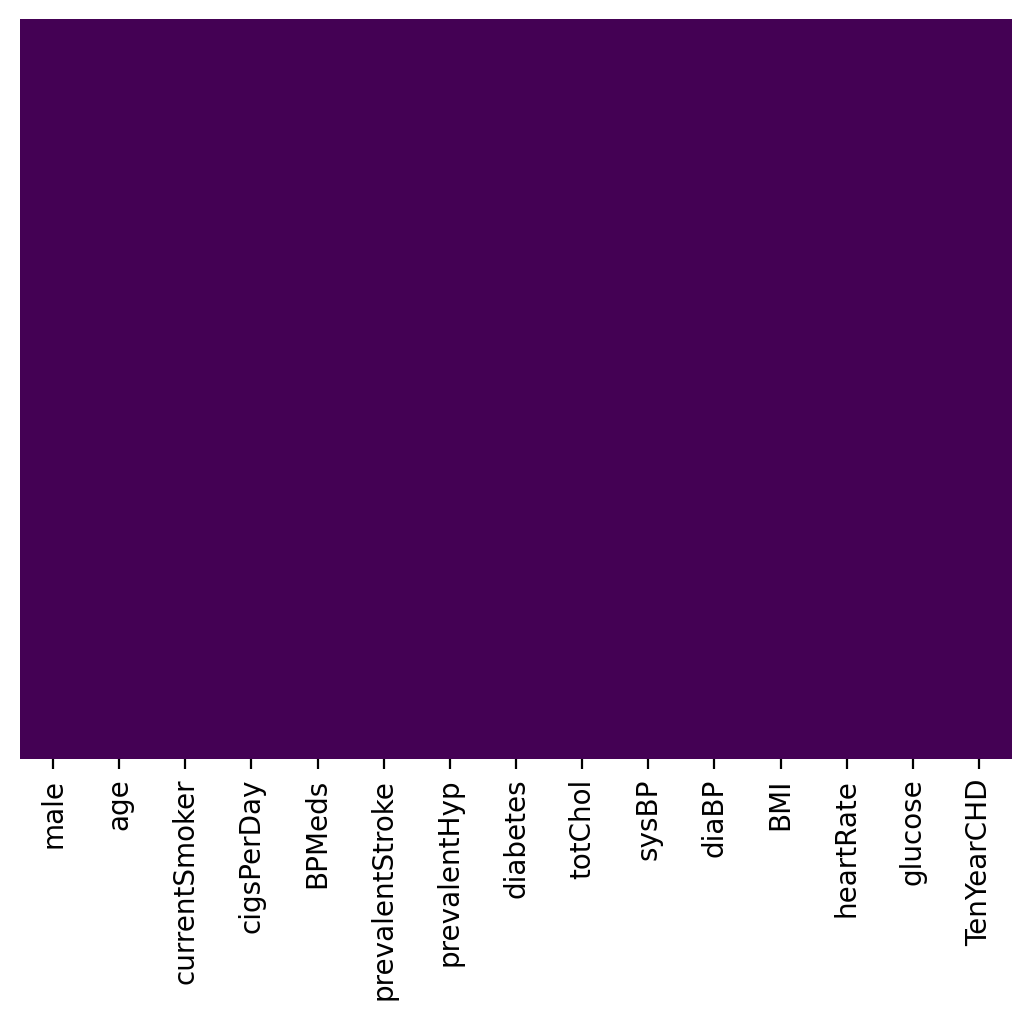

In [24]:
sns.heatmap( data.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')   

In [25]:
print(
    len(data[(data['male'] == 1) & (data['TenYearCHD'] == 1)]), # 343
    len(data[(data['male'] == 1) & (data['TenYearCHD'] == 0)]), # 1476
    len(data[(data['male'] == 0) & (data['TenYearCHD'] == 1)]), # 301
    len(data[(data['male'] == 0) & (data['TenYearCHD'] == 0)])  # 2118
) 

343 1476 301 2118


In [26]:
data.groupby('male')['TenYearCHD'].mean()

male
0    0.124432
1    0.188565
Name: TenYearCHD, dtype: float64

In [27]:
343 / (1476 + 343)

0.188565145684442

In [28]:
301 / (2118 + 301)

0.12443158329888383

In [29]:
0.188565145684442 / 0.12443158329888383

1.5154122505337715

In [30]:
data.groupby('male')['TenYearCHD'].mean()

male
0    0.124432
1    0.188565
Name: TenYearCHD, dtype: float64

In [31]:
freq_by_sex = data.groupby('male')['TenYearCHD'].mean()
p_female = freq_by_sex[0]  # 0.188565145684442
p_male = freq_by_sex[1]    # 0.12443158329888383

print("Frequency of heart disease (TenYearCHD = 1):")
print(f"  Female: {p_female:.6f}  ({p_female*100:.2f}%)")
print(f"  Male:   {p_male:.6f}  ({p_male*100:.2f}%)")

# Calculate odds
odds_female = p_female / (1 - p_female)
odds_male   = p_male / (1 - p_male)
manual_or   = odds_male / odds_female

print("\nOdds of developing heart disease:")
print(f"  Female: {odds_female:.6f}")
print(f"  Male:   {odds_male:.6f}")
print(f"\nOdds ratio (Male / Female) = {manual_or:.6f}")
#Men are 63% more likely (in terms of odds) to develop heart disease than women.

Frequency of heart disease (TenYearCHD = 1):
  Female: 0.124432  (12.44%)
  Male:   0.188565  (18.86%)

Odds of developing heart disease:
  Female: 0.142115
  Male:   0.232385

Odds ratio (Male / Female) = 1.635186


In [32]:
X = data.drop('TenYearCHD', axis = 1)

In [33]:
y = data['TenYearCHD']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30)

In [35]:
scaler = StandardScaler()

In [36]:
scaled_x_train = scaler.fit_transform(X_train)
scaled_x_test = scaler.fit_transform(X_test)

In [37]:
model = LogisticRegression()

In [38]:
model.fit(scaled_x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
y_pred = model.predict(scaled_x_test)

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93      1102
           1       0.59      0.09      0.16       170

    accuracy                           0.87      1272
   macro avg       0.73      0.54      0.55      1272
weighted avg       0.84      0.87      0.83      1272



In [41]:
def plot_metrics(model, x_test, y_test):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, ax=axes[0])
    RocCurveDisplay.from_estimator(model, x_test, y_test, ax=axes[1])
    PrecisionRecallDisplay.from_estimator(model, x_test, y_test, ax=axes[2])
    axes[0].set_title("Confusion Matrix")
    axes[1].set_title("ROC Curve")
    axes[2].set_title("Precision-Recall Curve")
    plt.tight_layout()
    plt.show()

In [42]:
accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred)

(0.8702830188679245, 0.5925925925925926, 0.09411764705882353)

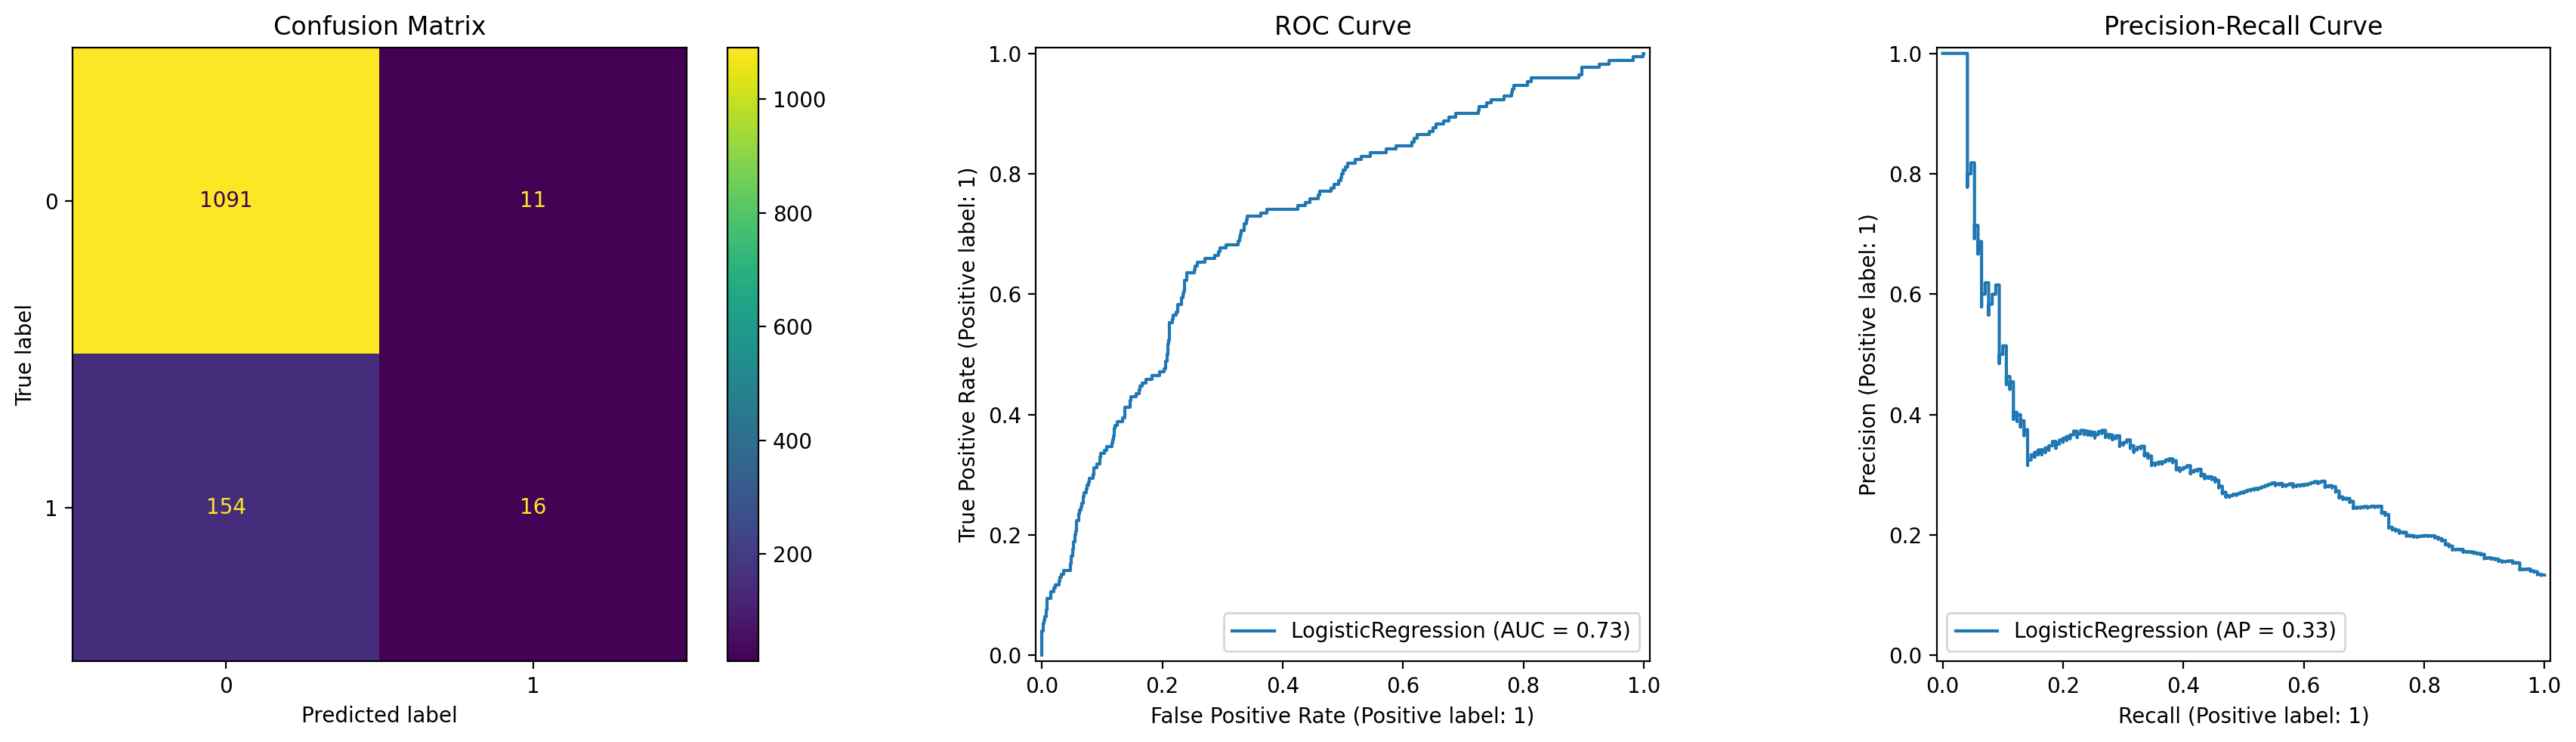

In [43]:
plot_metrics(model, scaled_x_test, y_test)

In [44]:
data['TenYearCHD'].value_counts()

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

In [45]:
model_balanced = LogisticRegression(class_weight = 'balanced', max_iter = 5000)

In [46]:
model_balanced.fit(scaled_x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [47]:
y_pred_balanced = model_balanced.predict(scaled_x_test)

In [48]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.93      0.67      0.78      1102
           1       0.25      0.69      0.36       170

    accuracy                           0.68      1272
   macro avg       0.59      0.68      0.57      1272
weighted avg       0.84      0.68      0.73      1272



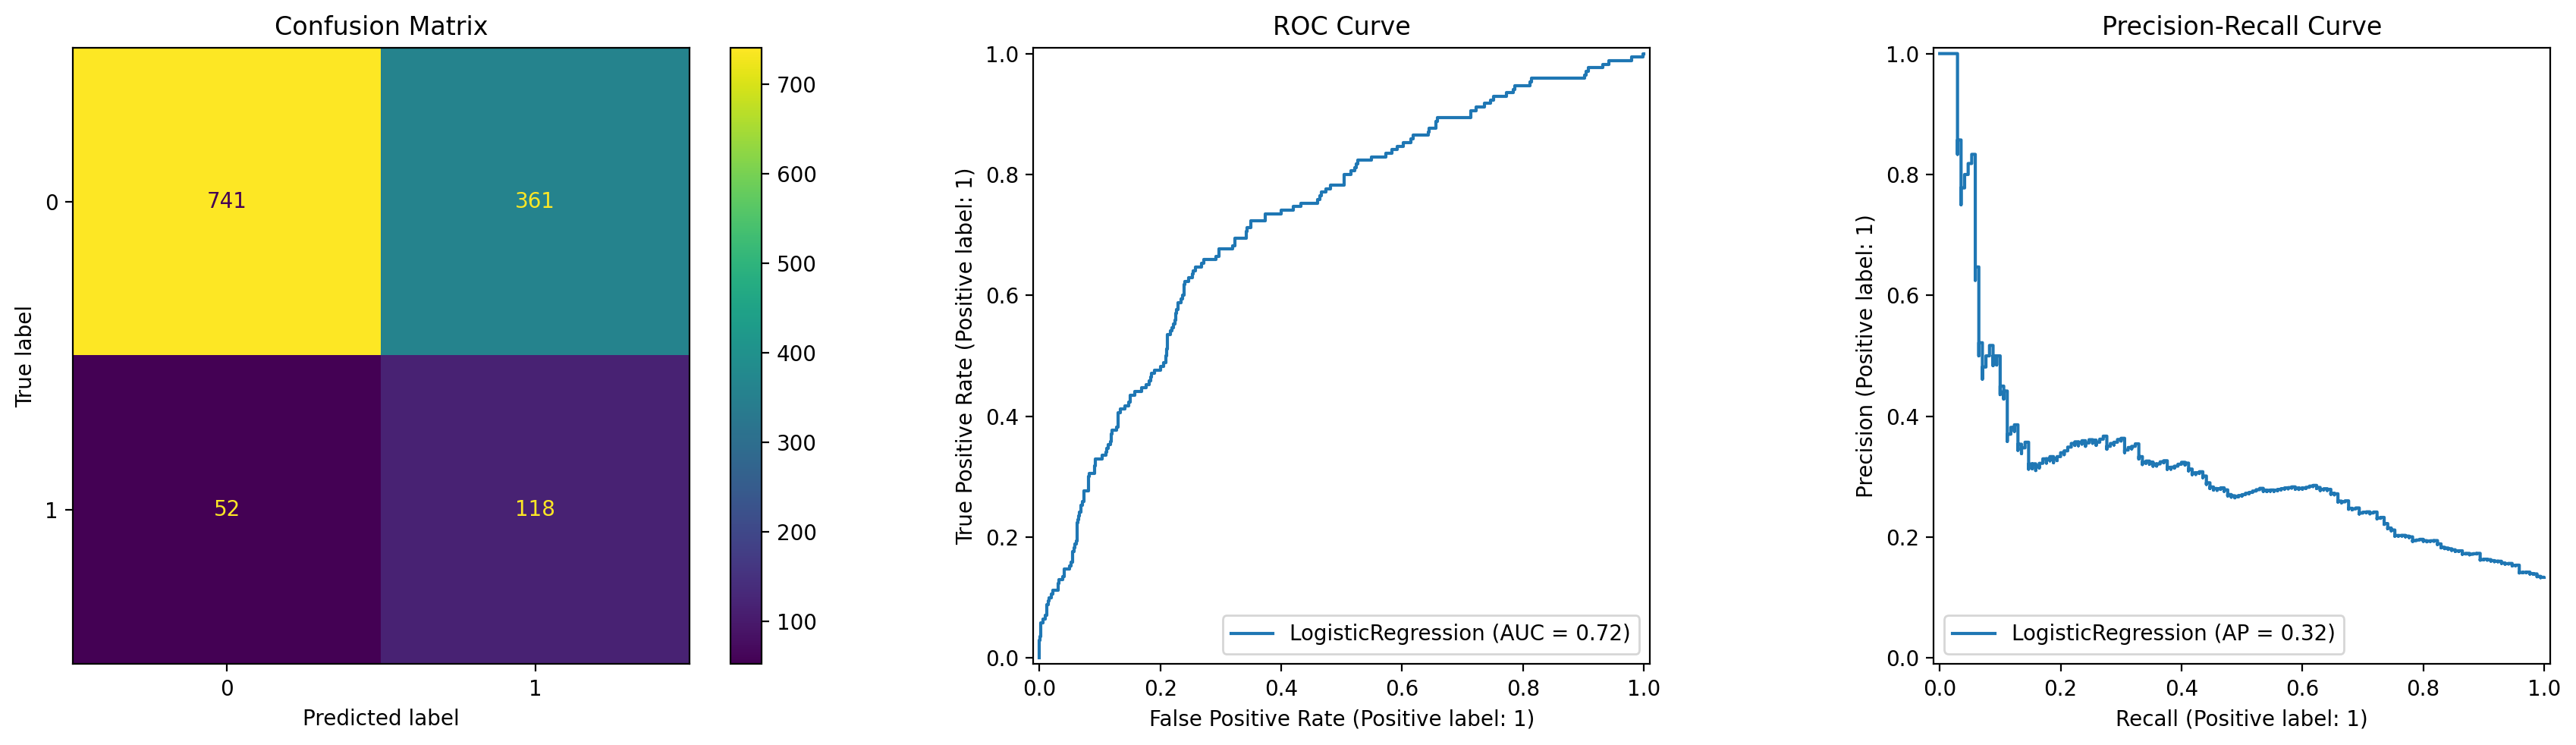

In [49]:
plot_metrics(model_balanced, scaled_x_test, y_test)

In [50]:
model_cv = LogisticRegressionCV(class_weight = 'balanced', max_iter = 5000)

In [51]:
model_cv.fit(scaled_x_train, y_train)

,Cs,10
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,5000
,class_weight,'balanced'
,n_jobs,None


In [52]:
y_pred_cv = model_cv.predict(scaled_x_test)

In [53]:
print(classification_report(y_test, y_pred_cv))

              precision    recall  f1-score   support

           0       0.92      0.70      0.80      1102
           1       0.24      0.63      0.35       170

    accuracy                           0.69      1272
   macro avg       0.58      0.66      0.57      1272
weighted avg       0.83      0.69      0.74      1272



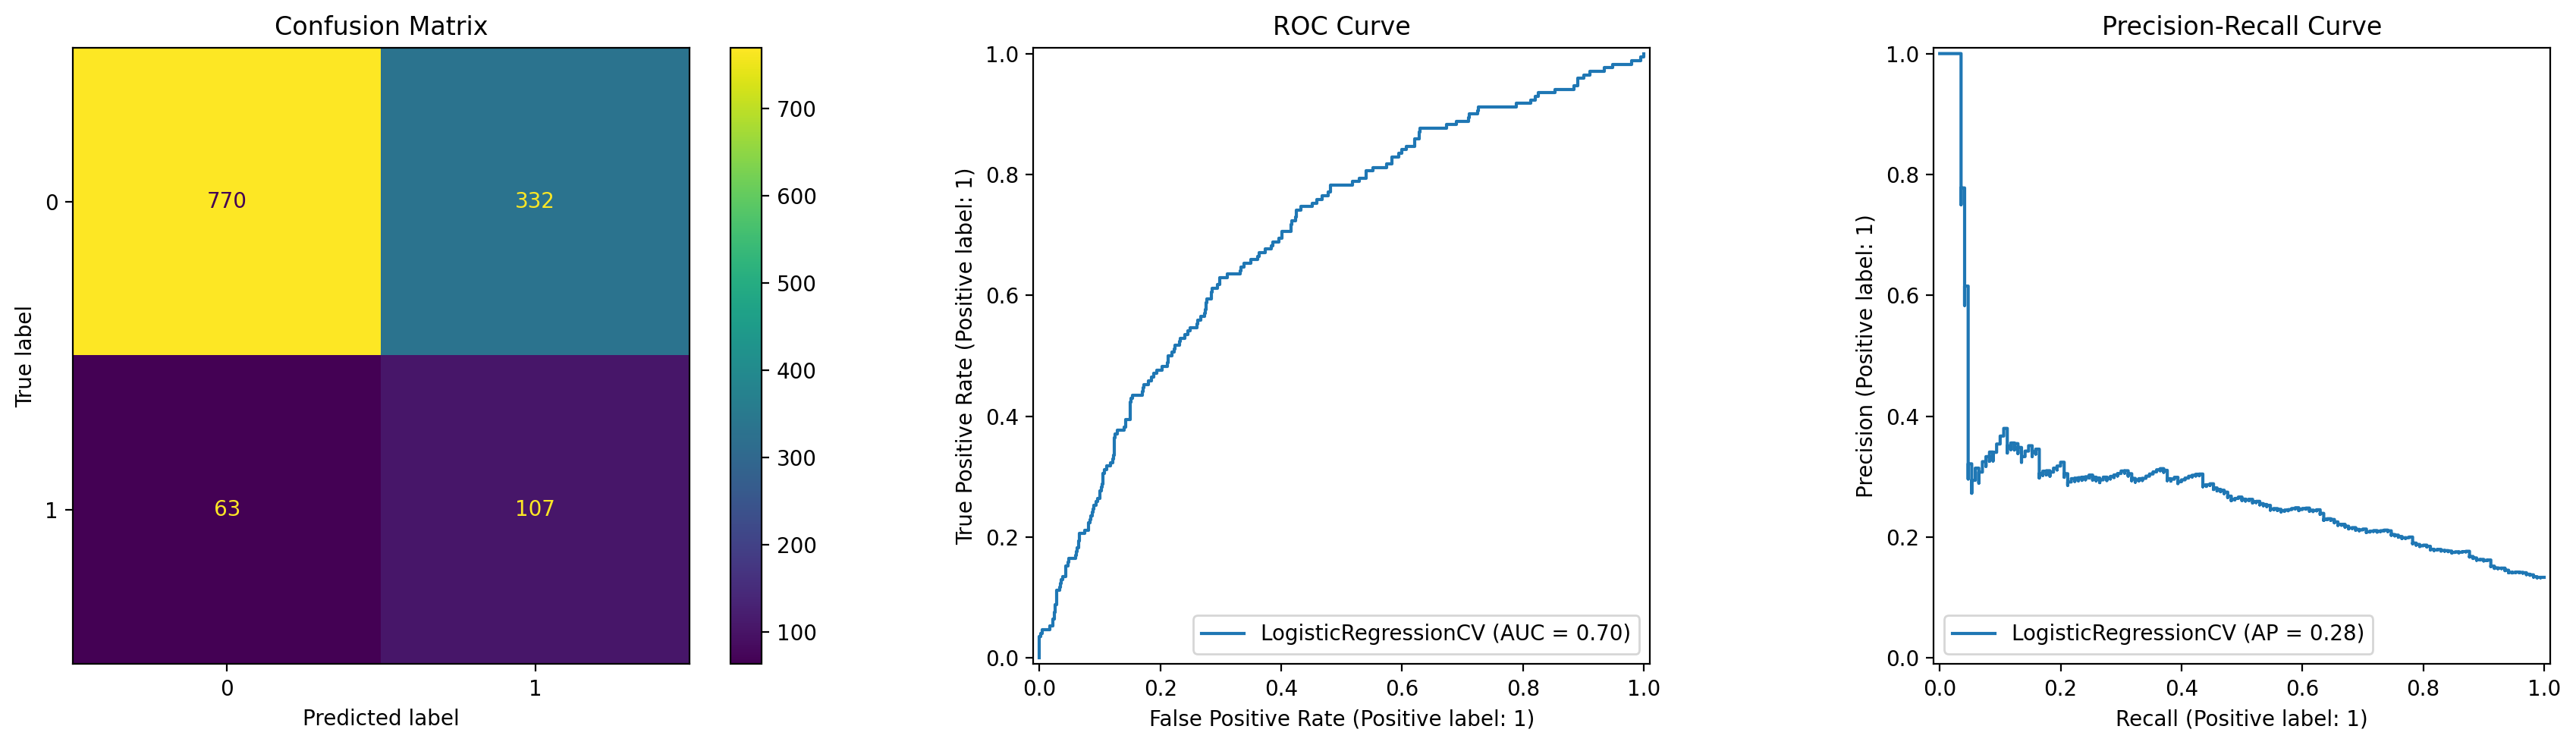

In [54]:
plot_metrics(model_cv, scaled_x_test, y_test)

In [55]:
model.coef_, model.intercept_

(array([[0.23601122, 0.54147968, 0.01143707, 0.24205075, 0.08925101,
         0.08364171, 0.03667269, 0.07043541, 0.09076404, 0.28054654,
         0.04468651, 0.04252538, 0.00218582, 0.10693574]]),
 array([-1.91064428]))

In [56]:
model_balanced.coef_, model_balanced.intercept_

(array([[ 0.22065643,  0.57802242,  0.0375041 ,  0.23974553,  0.10907602,
          0.08632478,  0.02489685,  0.10653145,  0.10194589,  0.27323594,
          0.0518011 ,  0.07680012, -0.00756892,  0.06541488]]),
 array([-0.26106127]))

In [57]:
model_cv.coef_[0], model_cv.intercept_

(array([0.01606607, 0.0406336 , 0.00482084, 0.01101896, 0.01785314,
        0.012531  , 0.02755429, 0.01530792, 0.0144905 , 0.0358765 ,
        0.02450848, 0.01316323, 0.0035072 , 0.01658316]),
 array([-0.03413576]))

In [58]:
feature_names = pd.DataFrame(X).columns.tolist()  # список названий колонок
coefficients = model_balanced.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds Ratio': np.exp(coefficients)
})
coef_df = coef_df.sort_values(by = 'Odds Ratio', ascending = False)
print(coef_df)

            Feature  Coefficient  Odds Ratio
1               age     0.578022    1.782510
9             sysBP     0.273236    1.314210
3        cigsPerDay     0.239746    1.270926
0              male     0.220656    1.246895
4            BPMeds     0.109076    1.115247
7          diabetes     0.106531    1.112413
8           totChol     0.101946    1.107324
5   prevalentStroke     0.086325    1.090160
11              BMI     0.076800    1.079826
13          glucose     0.065415    1.067602
10            diaBP     0.051801    1.053166
2     currentSmoker     0.037504    1.038216
6      prevalentHyp     0.024897    1.025209
12        heartRate    -0.007569    0.992460


In [59]:
y_probs = model_cv.predict_proba(scaled_x_test)[:, 1]

def interactive_threshold(threshold):
    y_pred = (y_probs >= threshold).astype(int)
    precision = precision_score(y_test, y_pred, zero_division = 0)
    recall = recall_score(y_test, y_pred, zero_division = 0)
    f1 = f1_score(y_test, y_pred, zero_division = 0)
    
    print(f"Threshold: {threshold:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")
    print(f"F1 Score:  {f1:.2f}")
    print("Confusion Matrix:")
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

interact(interactive_threshold, threshold=FloatSlider(value=0.5, min=0, max=1, step=0.01));

interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0, step=0.01), Output()), _dom_cla…

In [60]:
X = scaler.fit_transform(X)

In [61]:
model_final = LogisticRegressionCV(class_weight = 'balanced', max_iter = 5000)

In [62]:
model_final.fit(X, y)

,Cs,10
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,5000
,class_weight,'balanced'
,n_jobs,None


In [63]:
model_final.coef_, model_final.intercept_

(array([[0.0233646 , 0.05525898, 0.00691167, 0.01672067, 0.0172585 ,
         0.01362112, 0.03784083, 0.01979598, 0.01822022, 0.04662526,
         0.02884201, 0.01452124, 0.00340294, 0.02477022]]),
 array([-0.04480332]))

In [65]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


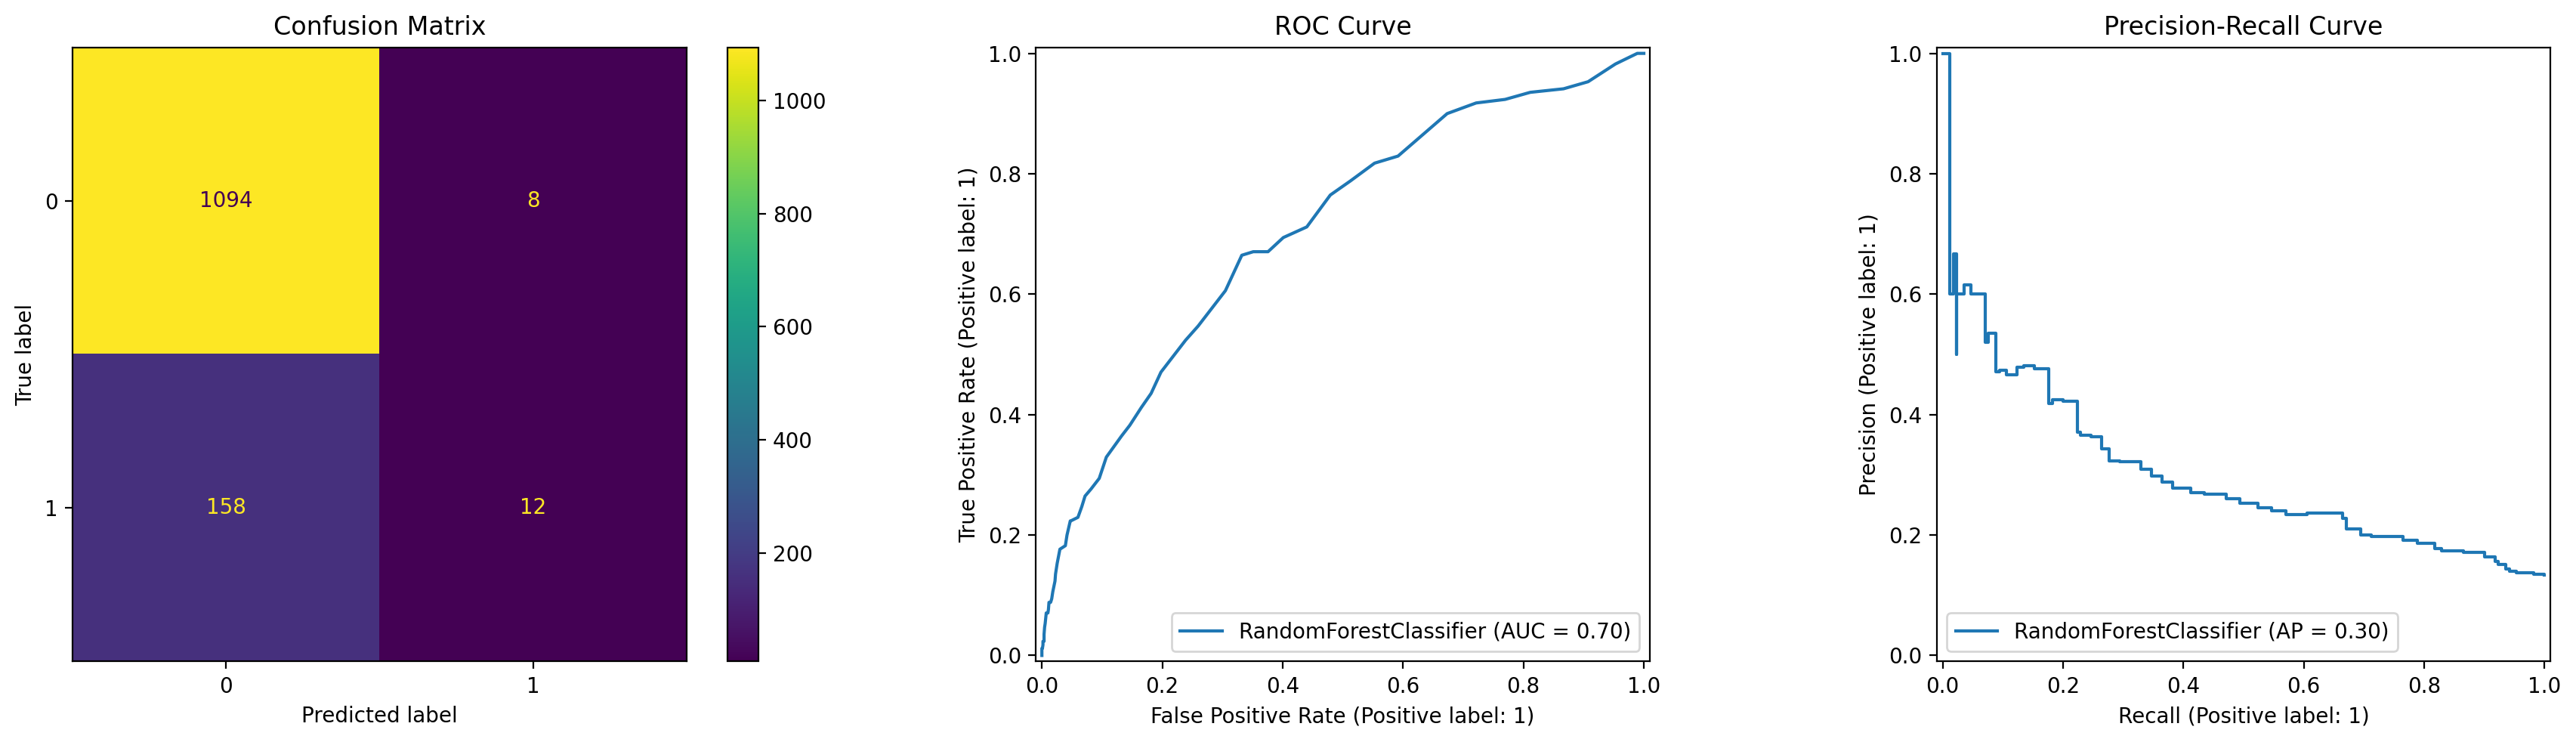

In [66]:
plot_metrics(rfc, X_test, y_test)

In [67]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93      1102
           1       0.59      0.09      0.16       170

    accuracy                           0.87      1272
   macro avg       0.73      0.54      0.55      1272
weighted avg       0.84      0.87      0.83      1272

